# 03 - Load fitted parameters and plot cross-station histograms

Produces:
- `figures/histogram_dry_spell_distrib_params.pdf` (Fig. 4 — $\hat f_1$, $\hat \xi$, $\hat \sigma$, $\hat \kappa$)
- `figures/histogram_wet_spell_distrib_params.pdf` (Fig. 5 — $\hat \pi$, $\hat p_1$, $\hat p_2$)

The hdeGPD fit comes from R (`R_files/fit_europe_spells_1945_threshold_JSON_ext_gpd/`). The wet-spell mixture EM runs in-notebook.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from article_code.util_files import config, plotting
from article_code.util_files.spell_models import *

SEASONS = config.SEASONS
NAME_STATION_EXAMPLE = config.STATION_EXAMPLE

## Fig. 4 - Histograms of the dry-spell hdeGPD parameters

In [2]:
# Load saved results from notebook 01.
name_folder_save_results = (f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}")
path_folder_save_results = config.RESULTS_FIT_DIR / name_folder_save_results
path_mixt_geom_fit_wet_spells = path_folder_save_results / "wet_spell_fit_mixt_geomresult_fit_parameters.csv"
pth_hdegpd_fit_dry_spells = path_folder_save_results / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv"
df_fit_wet = pd.read_csv(path_mixt_geom_fit_wet_spells)
df_fit_dry = pd.read_csv(pth_hdegpd_fit_dry_spells)
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s:s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s:s.split()[-1])
# Load dry-spell durations for Palermo from the JSON exported by notebook 01.
with open(config.EXPORTS_JSON_DIR / 
          f'ecad_data_south_europe_filtered_after_1946_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json') as fh:
    spells = json.load(fh)
palermo_spells = spells[NAME_STATION_EXAMPLE]['dry_spell']['duration_spell']
palermo_dates = spells[NAME_STATION_EXAMPLE]['dry_spell']['start_date_spell']
palermo_months = np.array([str(s)[4:6] for s in palermo_dates])

WindowsPath('C:/Users/antoi/Desktop/code/companion_code_article/figures/PALERMO/histogram_dry_spell_distrib_params.pdf')

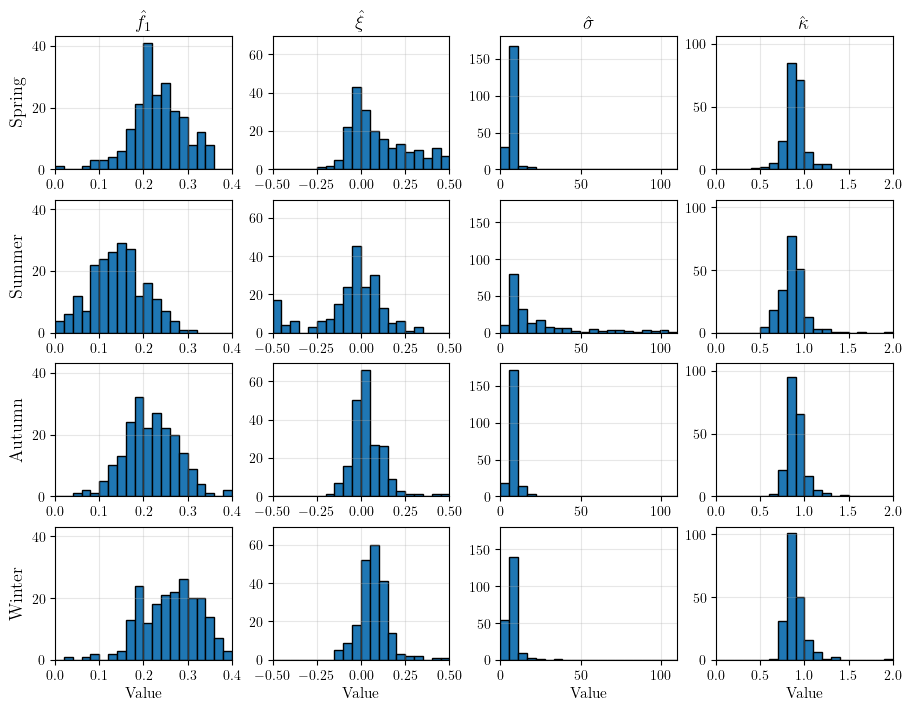

In [3]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
params = ['f_1', 'xi', 'sigma', 'kappa']
labels = [r'$\hat f_1$', r'$\hat \xi$', r'$\hat \sigma$', r'$\hat \kappa$']

xlims = {
    'f_1':   (0, 0.4),
    'xi':    (-0.5, 0.5),
    'sigma': (0, 110),
    'kappa': (0, 2),
}

# Pre-compute bins (20) and shared y-limit per parameter
bins_dict, ylims = {}, {}
for p in params:
    xmin, xmax = xlims[p]
    bins = np.linspace(xmin, xmax, 21)
    bins_dict[p] = bins
    ymax = 0
    for season in SEASONS:
        vals = df_fit_dry.loc[df_fit_dry['season'] == season, p].dropna().values
        counts, _ = np.histogram(vals, bins=bins)
        if counts.size:
            ymax = max(ymax, counts.max())
    ylims[p] = (0, ymax * 1.05)

fig, axes = plt.subplots(
    nrows=len(SEASONS), ncols=len(params),
    figsize=(9, 7), constrained_layout=True,
)
for i, season in enumerate(SEASONS):
    sub = df_fit_dry[df_fit_dry['season'] == season]
    for j, (p, lab) in enumerate(zip(params, labels)):
        ax = axes[i, j]
        ax.hist(sub[p].dropna().values, bins=bins_dict[p], edgecolor='black')
        ax.set_xlim(*xlims[p])
        ax.set_ylim(*ylims[p])
        if i == 0:
            ax.set_title(lab, fontsize=14)
        if j == 0:
            ax.set_ylabel(season.capitalize(), fontsize=13)
        if i == len(SEASONS) - 1:
            ax.set_xlabel('Value', fontsize=11)
        ax.grid(alpha=0.3)

plotting.save_dry_param_hist(fig)

## Fig. 5 - Histograms of the wet-spell geometric-mixture parameters (EM per station/season)

WindowsPath('C:/Users/antoi/Desktop/code/companion_code_article/figures/PALERMO/histogram_wet_spell_distrib_params.pdf')

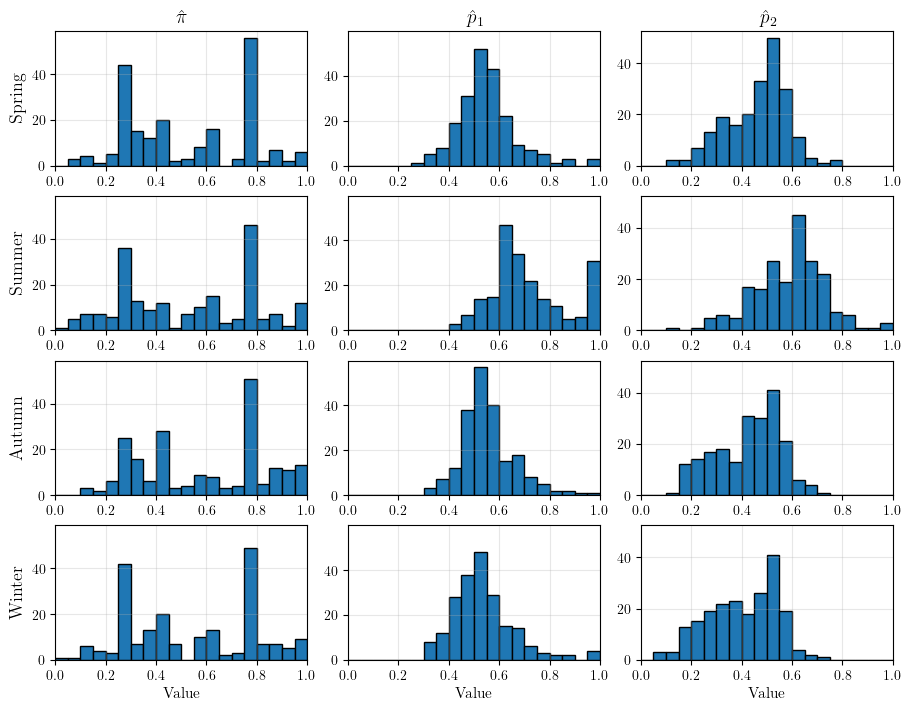

In [4]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

params = ['pi', 'p1', 'p2']
labels = [r'$\hat \pi$', r'$\hat p_1$', r'$\hat p_2$']

xlims = {'pi': (0, 1), 'p1': (0, 1), 'p2': (0, 1)}
bins_dict = {}
ylims = {}

# Shared bins and y-limits per parameter (across seasons)
for p in params:
    xmin, xmax = xlims[p]
    bins = np.linspace(xmin, xmax, 21)   # 20 bins
    bins_dict[p] = bins
    ymax = 0
    for season in SEASONS:
        vals = df_fit_wet.loc[df_fit_wet['season'] == season, p].dropna().values
        counts, _ = np.histogram(vals, bins=bins)
        ymax = max(ymax, counts.max())
    ylims[p] = (0, ymax * 1.05)

fig, axes = plt.subplots(nrows=len(SEASONS), ncols=len(params),
                         figsize=(9, 7), constrained_layout=True)

for i, season in enumerate(SEASONS):
    sub = df_fit_wet[df_fit_wet['season'] == season]
    for j, (p, lab) in enumerate(zip(params, labels)):
        ax = axes[i, j]
        ax.hist(sub[p].dropna().values, bins=bins_dict[p], edgecolor='black')
        ax.set_xlim(*xlims[p])
        ax.set_ylim(*ylims[p])
        if i == 0:
            ax.set_title(lab, fontsize=14)
        if j == 0:
            ax.set_ylabel(season.capitalize(), fontsize=13)
        if i == len(SEASONS) - 1:
            ax.set_xlabel('Value', fontsize=11)
        ax.grid(alpha=0.3)

plotting.save_wet_param_hist(fig)